## GNN Lesson 2: Node Classification with a GCN
### What you'll learn
- The simplest GNN: Graph Convolutional Network (GCN) by Kipf & Welling (2017).
- "Message passing" — each node updates its features by aggregating from neighbours.
- Train a 2-layer GCN on a per-residue prediction task.
- Why a GNN can outperform a per-residue MLP for context-dependent tasks.

### The toy task
Predict whether each residue is a "hydrophobic core residue", defined as:
  1. The residue itself is hydrophobic (A, V, L, I, F, M, W, Y), AND
  2. Most of its sequence-window neighbours are also hydrophobic.

Condition (2) makes this CONTEXT-DEPENDENT: a per-residue model that ignores
neighbours physically cannot solve it. A GNN can. We'll train both and compare.

### Real protein analogues
Many real per-residue tasks are similarly context-dependent:
  - Solvent accessibility (a residue is "buried" if surrounded by other residues)
  - Interface residues (binding face of a complex)
  - Catalytic site prediction

> **Run order matters.** The cells below build on each other. Run them **top to bottom** (Jupyter: *Run → Run All Cells*; VS Code: *Run All*). If you hit `NameError: name 'torch' is not defined` (or similar), you skipped the **Setup** cell — run it first.

## Setup — imports & configuration

**Run this cell first.** It imports every library and defines the module-level constants the rest of the notebook relies on.

In [1]:
import random
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv

# Shared building blocks live in gnn_common.py (same folder as this notebook).
# Make it importable whether Jupyter was launched from the repo root or gnn/.
import os, sys
_root = os.path.abspath("")
for _cand in (_root, os.path.join(_root, "gnn"), os.path.dirname(_root)):
    if os.path.isfile(os.path.join(_cand, "gnn_common.py")):
        if _cand not in sys.path:
            sys.path.insert(0, _cand)
        break
from gnn_common import (
    AMINO_ACIDS, AA_TO_IDX, HYDROPHOBIC,
    one_hot_aa, make_edge_index, draw_arch_stack,
)

### `label_residues` (function)

Per-residue label: 1 if residue is hydrophobic AND > threshold of its
sequence-window neighbours are hydrophobic, else 0.

In [2]:
def label_residues(sequence, window=3, hydro_threshold=0.6):
    n = len(sequence)
    labels = []
    for i in range(n):
        if sequence[i] not in HYDROPHOBIC:
            labels.append(0)
            continue
        # Look at neighbours within `window` residues, excluding self.
        lo, hi = max(0, i - window), min(n, i + window + 1)
        neighbours = sequence[lo:i] + sequence[i + 1 : hi]
        if not neighbours:
            labels.append(0)
            continue
        frac = sum(1 for aa in neighbours if aa in HYDROPHOBIC) / len(neighbours)
        labels.append(1 if frac >= hydro_threshold else 0)
    return torch.tensor(labels, dtype=torch.long)

### `make_dataset` (function)

Generate `n_graphs` random protein-like sequences with labels.

In [3]:
def make_dataset(n_graphs=200, length_range=(40, 120), seed=0):
    rng = random.Random(seed)
    data_list = []
    for _ in range(n_graphs):
        L = rng.randint(*length_range)
        seq = "".join(rng.choice(AMINO_ACIDS) for _ in range(L))
        data_list.append(
            Data(
                x=one_hot_aa(seq),
                edge_index=make_edge_index(L, window=3),
                y=label_residues(seq, window=3),
            )
        )
    return data_list

### `GCN` (class)

A bog-standard 2-layer GCN.

The Kipf-Welling layer's update rule is roughly:
    h_i' = sigma( W * mean_{j in N(i) union {i}} (h_j) )
i.e. each node's new feature vector is a weighted average of its own
feature vector and those of its neighbours, fed through a linear layer
and a non-linearity. Stack two of these and each node's output is
informed by its 2-hop neighbourhood.

In [4]:
class GCN(torch.nn.Module):

    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=0.2, training=self.training)
        return self.conv2(h, edge_index)

### `MLP` (class)

Per-node MLP — completely ignores edges. Baseline.

Same number of layers and hidden size as the GCN, so the only difference
between the two models is whether they USE the graph structure.

In [5]:
class MLP(torch.nn.Module):

    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.fc1 = torch.nn.Linear(in_channels, hidden_channels)
        self.fc2 = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):  # edge_index argument unused — that's the point
        return self.fc2(F.relu(self.fc1(x)))

### The two architectures, side by side

Same depth, same widths - the **only** difference is that the GCN's layers mix each residue with its neighbours (via `edge_index`), while the MLP treats every residue independently. The diagram makes that contrast explicit.

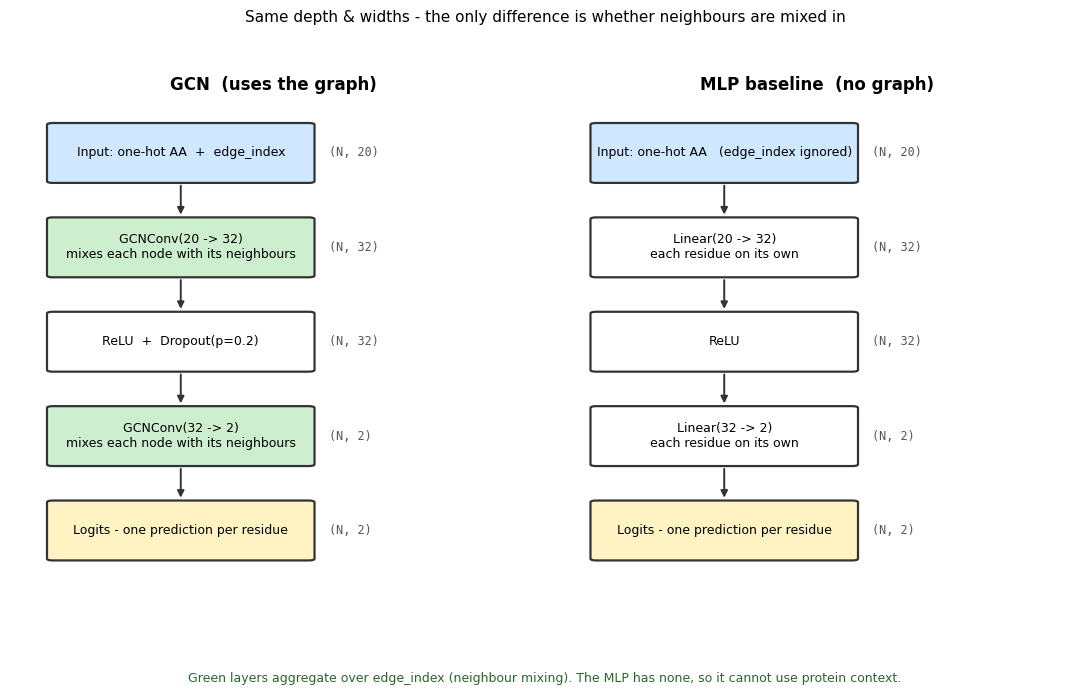

In [6]:
# Block diagram of the GCN vs the MLP, using draw_arch_stack from gnn_common.
# Shapes assume N residues and 20-dim one-hot input.
import matplotlib.pyplot as plt

LB, LG, WT, LY = '#cfe8ff', '#cdEFD0', '#ffffff', '#fff3c4'
gcn_layers = [
    ('Input: one-hot AA  +  edge_index', '(N, 20)', LB),
    ('GCNConv(20 -> 32)|mixes each node with its neighbours', '(N, 32)', LG),
    ('ReLU  +  Dropout(p=0.2)', '(N, 32)', WT),
    ('GCNConv(32 -> 2)|mixes each node with its neighbours', '(N, 2)', LG),
    ('Logits - one prediction per residue', '(N, 2)', LY),
]
mlp_layers = [
    ('Input: one-hot AA   (edge_index ignored)', '(N, 20)', LB),
    ('Linear(20 -> 32)|each residue on its own', '(N, 32)', WT),
    ('ReLU', '(N, 32)', WT),
    ('Linear(32 -> 2)|each residue on its own', '(N, 2)', WT),
    ('Logits - one prediction per residue', '(N, 2)', LY),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 7))
draw_arch_stack(axes[0], 'GCN  (uses the graph)', gcn_layers)
draw_arch_stack(axes[1], 'MLP baseline  (no graph)', mlp_layers)
fig.suptitle('Same depth & widths - the only difference is whether neighbours are mixed in',
             fontsize=11, y=0.98)
fig.text(0.5, 0.02,
         'Green layers aggregate over edge_index (neighbour mixing). '
         'The MLP has none, so it cannot use protein context.',
         ha='center', fontsize=9, color='#2a662e')
plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()

### `train_and_eval` (function)

In [7]:
def train_and_eval(model, train_loader, test_loader, device, epochs=20, lr=1e-2):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for ep in range(epochs):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            # PyG's DataLoader BATCHES multiple graphs into a single big graph
            # with a `batch.batch` tensor that says which graph each node is in.
            # Message passing respects the batch boundaries automatically — no
            # edges between separate graphs.
            batch = batch.to(device)
            opt.zero_grad()
            logits = model(batch.x, batch.edge_index)
            loss = F.cross_entropy(logits, batch.y)
            loss.backward()
            opt.step()
            total_loss += loss.item()

        if (ep + 1) % 5 == 0:
            acc = evaluate(model, test_loader, device)
            print(f"  epoch {ep + 1:3d}  loss={total_loss / len(train_loader):.3f}  test_acc={acc:.3f}")

    return evaluate(model, test_loader, device)

### `evaluate` (function)

In [8]:
def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index)
        pred = logits.argmax(dim=-1)
        correct += (pred == batch.y).sum().item()
        total += batch.y.numel()
    return correct / total

### `main` (function)

In [9]:
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    print("\nGenerating synthetic protein graphs...")
    train_set = make_dataset(n_graphs=200, seed=0)
    test_set = make_dataset(n_graphs=50, seed=1)

    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=8)

    pos = sum((d.y == 1).sum().item() for d in train_set)
    total_y = sum(d.y.numel() for d in train_set)
    pos_frac = pos / total_y
    print(f"  Train graphs: {len(train_set)}, Test graphs: {len(test_set)}")
    print(f"  Total residues (train): {total_y}")
    print(f"  Fraction of positive labels: {pos_frac:.3f}")
    print(f"  Always-predict-majority accuracy: {max(pos_frac, 1 - pos_frac):.3f}")

    print("\n[1/2] Training MLP baseline (no neighbour info)...")
    mlp_acc = train_and_eval(MLP(20, 32, 2), train_loader, test_loader, device)
    print(f"  Final MLP accuracy: {mlp_acc:.3f}")

    print("\n[2/2] Training GCN (uses neighbours via message passing)...")
    gcn_acc = train_and_eval(GCN(20, 32, 2), train_loader, test_loader, device)
    print(f"  Final GCN accuracy: {gcn_acc:.3f}")

    print(f"\nDelta (GCN - MLP): {gcn_acc - mlp_acc:+.3f}")
    print("If they're roughly tied, the task is too easy or the window is too small.")

    print(
        """
Things to experiment with:
- Add a third GCN layer — output now reflects 3-hop neighbourhoods.
- Drop GCN to 1 layer — should drop to MLP-level performance.
- Make the task harder: hydro_threshold=0.8, smaller window.
- Replace GCNConv with SAGEConv (GraphSAGE) or GINConv (GIN) — different
  aggregation schemes, similar API.
- Use ATTENTION via GATConv: lets the model learn which neighbours matter.
"""
    )

## Run the lesson

Execute everything above, then run `main()`.

In [10]:
main()

Using device: cuda

Generating synthetic protein graphs...
  Train graphs: 200, Test graphs: 50
  Total residues (train): 15766
  Fraction of positive labels: 0.081
  Always-predict-majority accuracy: 0.919

[1/2] Training MLP baseline (no neighbour info)...


  epoch   5  loss=0.205  test_acc=0.917
  epoch  10  loss=0.203  test_acc=0.917


  epoch  15  loss=0.205  test_acc=0.917
  epoch  20  loss=0.205  test_acc=0.917
  Final MLP accuracy: 0.917

[2/2] Training GCN (uses neighbours via message passing)...


  epoch   5  loss=0.153  test_acc=0.917


  epoch  10  loss=0.129  test_acc=0.942


  epoch  15  loss=0.119  test_acc=0.949


  epoch  20  loss=0.113  test_acc=0.951
  Final GCN accuracy: 0.951

Delta (GCN - MLP): +0.034
If they're roughly tied, the task is too easy or the window is too small.

Things to experiment with:
- Add a third GCN layer — output now reflects 3-hop neighbourhoods.
- Drop GCN to 1 layer — should drop to MLP-level performance.
- Make the task harder: hydro_threshold=0.8, smaller window.
- Replace GCNConv with SAGEConv (GraphSAGE) or GINConv (GIN) — different
  aggregation schemes, similar API.
- Use ATTENTION via GATConv: lets the model learn which neighbours matter.



## What did the models actually learn?

The training loss is low — but a number isn't an explanation. Let's **train a GCN and an MLP, keep the models**, and look at their *per-residue* predictions: which residues each model calls a **hydrophobic-core** residue (label `1`) vs not (label `0`), and where the GCN's use of neighbours lets it win.

In [11]:
# Train both models and KEEP the objects (main() above trains then discards them).
device = "cuda" if torch.cuda.is_available() else "cpu"

train_set = make_dataset(n_graphs=200, seed=0)
test_set = make_dataset(n_graphs=50, seed=1)
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
test_loader = DataLoader(test_set, batch_size=8)

print("Training GCN (uses neighbours)...")
gcn = GCN(20, 32, 2)
gcn_acc = train_and_eval(gcn, train_loader, test_loader, device)

print()
print("Training MLP (ignores neighbours)...")
mlp = MLP(20, 32, 2)
mlp_acc = train_and_eval(mlp, train_loader, test_loader, device)

print()
print(f"GCN test accuracy = {gcn_acc:.3f}")
print(f"MLP test accuracy = {mlp_acc:.3f}")

Training GCN (uses neighbours)...


  epoch   5  loss=0.150  test_acc=0.922


  epoch  10  loss=0.112  test_acc=0.954


  epoch  15  loss=0.109  test_acc=0.955


  epoch  20  loss=0.110  test_acc=0.955

Training MLP (ignores neighbours)...


  epoch   5  loss=0.204  test_acc=0.917
  epoch  10  loss=0.204  test_acc=0.917


  epoch  15  loss=0.203  test_acc=0.917
  epoch  20  loss=0.205  test_acc=0.917

GCN test accuracy = 0.955
MLP test accuracy = 0.917


### Per-residue predictions on one protein

We pick the test protein with the most core residues (so the example isn't all zeros), reconstruct its amino-acid sequence from the one-hot node features, and tabulate **true vs GCN vs MLP** for each residue. `✓`/`✗` mark each model's hits and misses.

In [12]:
def predict(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.x.to(device), data.edge_index.to(device))
    return logits.argmax(dim=-1).cpu()

# Most-interesting test graph = the one with the most positive (core) labels.
g = max(test_set, key=lambda d: int((d.y == 1).sum()))
seq = "".join(AMINO_ACIDS[i] for i in g.x.argmax(dim=-1).tolist())
true, gcn_pred, mlp_pred = g.y, predict(gcn, g), predict(mlp, g)

print(f"Protein length {len(seq)}.  Label 1 = hydrophobic-core residue.")
print(f"{'pos':>3} {'aa':>2} {'self-hydrophobic':>16} {'true':>5} {'GCN':>5} {'MLP':>5}")
print("-" * 46)
for i in range(min(30, len(seq))):
    aa = seq[i]
    self_h = "yes" if aa in HYDROPHOBIC else "no"
    gtick = "ok" if int(gcn_pred[i]) == int(true[i]) else "XX"
    mtick = "ok" if int(mlp_pred[i]) == int(true[i]) else "XX"
    print(f"{i:>3} {aa:>2} {self_h:>16} {int(true[i]):>5} "
          f"{int(gcn_pred[i]):>4}{gtick} {int(mlp_pred[i]):>4}{mtick}")

print()
print(f"True core residues : {[i for i in range(len(seq)) if int(true[i]) == 1]}")
print(f"GCN says core      : {[i for i in range(len(seq)) if int(gcn_pred[i]) == 1]}")
print(f"MLP says core      : {[i for i in range(len(seq)) if int(mlp_pred[i]) == 1]}")

Protein length 70.  Label 1 = hydrophobic-core residue.
pos aa self-hydrophobic  true   GCN   MLP
----------------------------------------------


  0  G               no     0    0ok    0ok
  1  E               no     0    0ok    0ok
  2  Q               no     0    0ok    0ok
  3  P               no     0    0ok    0ok
  4  V              yes     0    0ok    0ok
  5  L              yes     0    0ok    0ok
  6  V              yes     0    0ok    0ok
  7  K               no     0    0ok    0ok
  8  S               no     0    0ok    0ok
  9  M              yes     0    0ok    0ok
 10  E               no     0    0ok    0ok
 11  H               no     0    0ok    0ok
 12  M              yes     0    0ok    0ok
 13  C               no     0    0ok    0ok
 14  A              yes     1    0XX    0XX
 15  A              yes     1    1ok    0XX
 16  L              yes     1    1ok    0XX
 17  Y              yes     1    1ok    0XX
 18  M              yes     1    0XX    0XX
 19  R               no     0    0ok    0ok
 20  P               no     0    0ok    0ok
 21  M              yes     0    0ok    0ok
 22  P               no     0   

### See it on the graph

The same protein as a graph. **Orange = predicted hydrophobic-core**, blue = not. A **red node outline = wrong** versus the true labels. The GCN panel should hug the truth far more closely than the MLP panel — that gap *is* the value of message passing.

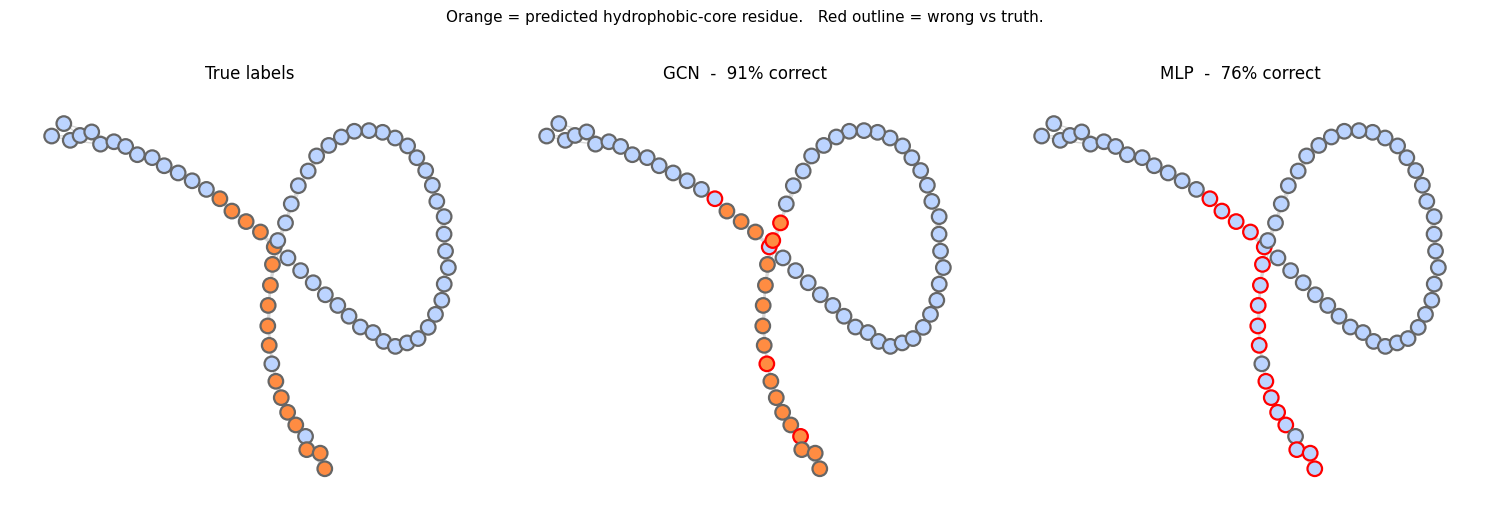

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(range(g.num_nodes))
for s, t in g.edge_index.t().tolist():
    G.add_edge(s, t)
layout = nx.spring_layout(G, seed=1)


def panel(ax, labels, title, ref=None):
    fill = ["#ff8c42" if int(l) == 1 else "#bcd4ff" for l in labels]
    outline = ["red" if (ref is not None and int(labels[n]) != int(ref[n])) else "0.4"
               for n in G.nodes()]
    nx.draw_networkx_edges(G, layout, ax=ax, edge_color="0.85")
    nx.draw_networkx_nodes(G, layout, ax=ax, node_color=fill, node_size=110,
                           edgecolors=outline, linewidths=1.6)
    ax.set_title(title)
    ax.axis("off")


acc_g = (gcn_pred == true).float().mean().item()
acc_m = (mlp_pred == true).float().mean().item()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
panel(axes[0], true, "True labels")
panel(axes[1], gcn_pred, f"GCN  -  {acc_g:.0%} correct", ref=true)
panel(axes[2], mlp_pred, f"MLP  -  {acc_m:.0%} correct", ref=true)
fig.suptitle("Orange = predicted hydrophobic-core residue.   Red outline = wrong vs truth.",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

### GCN vs MLP, overall

And the headline: test accuracy across the whole test set, against the always-predict-the-majority-class baseline.

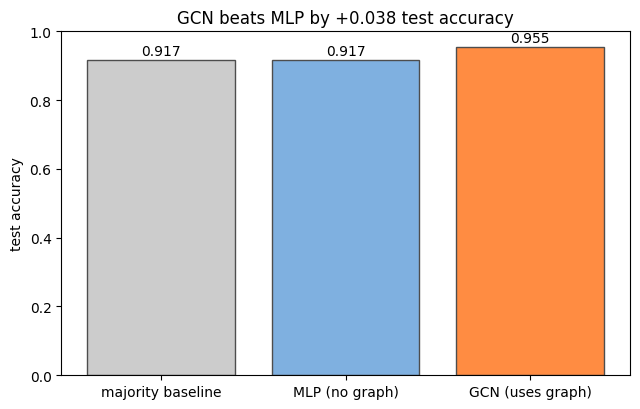

In [14]:
import matplotlib.pyplot as plt

pos = sum(int((d.y == 1).sum()) for d in test_set)
total = sum(d.y.numel() for d in test_set)
pos_frac = pos / total
baseline = max(pos_frac, 1 - pos_frac)

names = ["majority baseline", "MLP (no graph)", "GCN (uses graph)"]
vals = [baseline, mlp_acc, gcn_acc]
colors = ["#cccccc", "#7fb0e0", "#ff8c42"]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(names, vals, color=colors, edgecolor="0.3")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.006, f"{v:.3f}",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("test accuracy")
ax.set_ylim(0, 1.0)
ax.set_title(f"GCN beats MLP by {gcn_acc - mlp_acc:+.3f} test accuracy")
plt.tight_layout()
plt.show()